In [1]:
import plotly.io as pio
import gdown
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [3]:

FILE_ID = "1sf2LEsakAjMzEqayzZ-1maf0aYXHYm1a"
CSV_FILE = "area_crimetype_heatmap.json"

gdrive_dict = {#'area_crimetype_heatmap.json':'1sf2LEsakAjMzEqayzZ-1maf0aYXHYm1a',
            #    'diurnal_heatmap.json':'1RsLPtfXTXiMNHRWcYpHqN45MpPCfXPpD',
            #    'crime_choropleth_map.json':'10zDHrCXcWuwe8MtW1ctKf5FPtNS1hLTp',
            #    'time_series_seasonality.json':'1l5-chpbi_n3J8yAUytzF8mJD5jqshURA',
            #    'top_crime_annual.json':'1nV7WUgQHpmK-DGagmm5sGc5bOnFFeyco',
               'arrest_rate.png':'1U6JqhoYsaPMThrGGLOm3zpOH2swAk4oI'}

file_name = list(gdrive_dict.keys())


def get_data_from_gdrive(file_id, file_name):

    url = f"https://drive.google.com/uc?export=download&id={file_id}"

    gdown.download(url, file_name, quiet=False)

    file_type = file_name.split('.')[1]

    if file_type == 'json':
        file_read = pio.read_json(file_name)
    else:
        file_read = Image.open(file_name)
    return file_read


fig_heatmap_area_crime = get_data_from_gdrive(gdrive_dict[file_name[0]],file_name[0])

Downloading...
From: https://drive.google.com/uc?export=download&id=1U6JqhoYsaPMThrGGLOm3zpOH2swAk4oI
To: c:\Users\rizky\Documents\0.Coding\NUS\IT5006\Project\streamlit-deploy-test\IT5006Group\EDA\arrest_rate.png
100%|██████████| 268k/268k [00:00<00:00, 7.82MB/s]


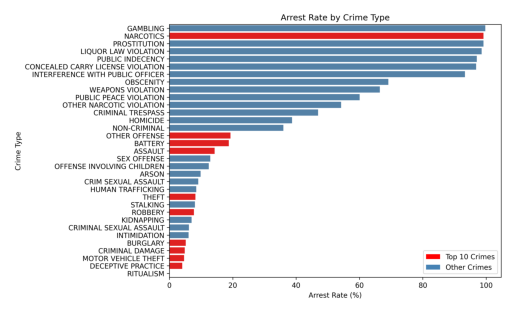

In [4]:



# img = Image.open("arrest_rate.png")
plt.imshow(fig_heatmap_area_crime)
plt.axis("off")
plt.show()

In [ ]:
import streamlit as st
import plotly.io as pio
import gdown
import os

gdrive_dict = {'area_crimetype_heatmap.json':'1TJiv9xgoa6Kaut-Oi8vL8-T2lngMB6zi',
               'diurnal_heatmap.json':'1RsLPtfXTXiMNHRWcYpHqN45MpPCfXPpD',
               'crime_choropleth_map.json':'10zDHrCXcWuwe8MtW1ctKf5FPtNS1hLTp',
               'time_series_seasonality.json':'1l5-chpbi_n3J8yAUytzF8mJD5jqshURA',
               'top_crime_annual.json':'1nV7WUgQHpmK-DGagmm5sGc5bOnFFeyco'}

file_name = list(gdrive_dict.keys())

file_name = list(gdrive_dict.keys())
if st.button("Reload charts"):
    st.cache_data.clear()

@st.cache_data
def get_data_from_gdrive(file_id, file_name):

    url = f"https://drive.google.com/uc?export=download&id={file_id}"

    gdown.download(url, file_name, quiet=False, fuzzy=True)

    json_file = pio.read_json(file_name)

    return json_file


def check_file(file_id,file_name):
    if os.path.exists(file_name):
        json_file = pio.read_json(file_name)
    else:
        json_file = get_data_from_gdrive(file_id,file_name)
    return json_file


fig_arrest_rate = 

# ========== MAIN PAGE ==========

st.title("Chicago Crime Dataset - Exploratory Data Analysis")


st.header("Crime Density Choropleth Map of Chicago")
st.plotly_chart(fig_choropleth, use_container_width=True)

st.header("Crime Occurence Time Series Seasonality")
st.plotly_chart(fig_time_series, use_container_width=True)

st.header("Highest Crime in Chicago Annually")
st.plotly_chart(fig_top_crime, use_container_width=True)

st.header("Heatmap of Chicago Community Area Crime Occurence")
st.plotly_chart(fig_heatmap_area_crime, use_container_width=True)

st.header("Heatmap of Diurnal Crime Occurence")
st.plotly_chart(fig_heatmap_diurnal, use_container_width=True)


# ========== SUMMARY PAGE ==========

st.title(f"Summary page is still empty 🙂, be patient")



In [ ]:
import plotly.io as pio


fig_heatmap_area_crime = pio.read_json("../jsonvis/area_crimetype_heatmap.json")
fig_heatmap_diurnal = pio.read_json("../jsonvis/diurnal_heatmap.json")
fig_choropleth = pio.read_json("../jsonvis/crime_choropleth_map.json")
fig_time_series = pio.read_json("../jsonvis/time_series_seasonality.json")
fig_top_crime = pio.read_json("../jsonvis/top_crime_annual.json")